# T8 — Análisis de Resultados y Tuning Fino del Modelo

**Tesis:** "Diseño e Implementación de un Sistema de Recomendación Laboral  
para Optimizar el Matching entre Candidatos y Ofertas de Empleo"  
**Alumno:** Cicconi, Carlos Alberto  
**Maestría:** Explotación de Datos y Gestión del Conocimiento — Universidad Austral  
**Período:** 02/03/2026 – 16/03/2026

---

## Objetivos de esta etapa

| # | Objetivo |
|---|----------|
| 1 | Analizar en profundidad los resultados del benchmark (T7): intérpretación, errores y patrones |
| 2 | Analizar el comportamiento del sistema por idioma (ES vs EN) y por keyword |
| 3 | **Tuning A:** optimizar la ponderación híbrida w_embed mediante grid search |
| 4 | **Tuning B:** analizar sensibilidad de métricas ante distintos umbrales de relevancia θ |
| 5 | **Tuning C:** optimizar hiperparámetros del vectorizador TF-IDF |
| 6 | Determinar la **configuración óptima** y generar el ranking final ajustado |
| 7 | Documentar la ganancia sobre el sistema base de T6 |

## Inputs
- `benchmark_resultados.csv` — scores de los 5 sistemas por oferta + relevancia (T7)
- `benchmark_metricas.json` — tabla comparativa de métricas (T7)
- `ofertas_preprocesadas.csv` — corpus con `similitud_tfidf`, `similitud_embed`, `idioma`
- `embeddings_ofertas.npy` / `embedding_cv.npy` — vectores SBERT (T5)
- `tfidf_vectorizer.pkl` / `tfidf_matrix.pkl` — vectorizador TF-IDF (T4)
- `cv_texto_limpio.txt` — texto CV lematizado

## Outputs
- `config_optima.json` — configuración óptima del motor
- `ranking_final_optimizado.csv` — ranking con la configuración tuneada
- `tuning_resultados.csv` — resultados completos del grid search
- `fig_t8_*.png` — gráficos para la tesis


## 0. Configuración del entorno

In [1]:
import re
import json
import pickle
import warnings
import itertools
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})

print('✅ Entorno configurado')
print(f'   pandas {pd.__version__}  |  numpy {np.__version__}')

# ── Rutas del proyecto (resueltas desde la ubicación del notebook) ────────────
from pathlib import Path
_NB   = Path(globals().get('__vsc_ipynb_file__', Path.cwd())).resolve()
_ROOT = _NB.parent if _NB.name != 'notebooks' else _NB.parent
if _ROOT.name == 'notebooks': _ROOT = _ROOT.parent
_PROC      = _ROOT / 'data'    / 'processed'
_CVDIR     = _ROOT / 'data'    / 'cvs'
_EMBEDDINGS= _ROOT / 'data'    / 'embeddings'
_MODELS    = _ROOT / 'outputs' / 'models'
_RANKINGS  = _ROOT / 'outputs' / 'rankings'
_REPORTS   = _ROOT / 'outputs' / 'reports'
_FIGS      = _ROOT / 'outputs' / 'figures'
_PROC.mkdir(parents=True, exist_ok=True)
_RANKINGS.mkdir(parents=True, exist_ok=True)
_REPORTS.mkdir(parents=True, exist_ok=True)
_FIGS.mkdir(parents=True, exist_ok=True)
print(f'ROOT       : {_ROOT}')
print(f'PROC       : {_PROC}')
print(f'EMBEDDINGS : {_EMBEDDINGS}')
print(f'MODELS     : {_MODELS}')
print(f'RANKINGS   : {_RANKINGS}')
print(f'REPORTS    : {_REPORTS}')
print(f'FIGS       : {_FIGS}')


✅ Entorno configurado
   pandas 2.2.3  |  numpy 2.2.4
ROOT       : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD
PROC       : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/data/processed
EMBEDDINGS : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/data/embeddings
MODELS     : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/models
RANKINGS   : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/rankings
REPORTS    : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/reports
FIGS       : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/figures


## 1. Carga de artefactos

In [2]:
# ── Corpus base ──────────────────────────────────────────────────────────────
for fpath in [_PROC / 'ofertas_preprocesadas.csv', _PROC / 'ofertas_con_descripcion.csv']:
    if fpath.exists():
        df = pd.read_csv(fpath, low_memory=False)
        fname = fpath.name
        df = df[df['descripcion'].fillna('').str.len() > 50].reset_index(drop=True)
        print(f'✅ {fname} — {len(df):,} filas x {df.shape[1]} cols')
        break
else:
    raise FileNotFoundError(f'No se encontró el corpus en {_PROC}.')

tiene_embed = 'similitud_embed' in df.columns and df['similitud_embed'].notna().any()
tiene_tfidf = 'similitud_tfidf' in df.columns and df['similitud_tfidf'].notna().any()
tiene_idioma = 'idioma' in df.columns
print(f'   similitud_embed: {"✅" if tiene_embed else "❌"}  |  '
      f'similitud_tfidf: {"✅" if tiene_tfidf else "❌"}  |  '
      f'idioma: {"✅" if tiene_idioma else "❌"}')


✅ ofertas_preprocesadas.csv — 2,476 filas x 18 cols
   similitud_embed: ❌  |  similitud_tfidf: ✅  |  idioma: ✅


In [3]:
# ── Benchmark (T7) ───────────────────────────────────────────────────────────
bench_disp = False
if (_RANKINGS / 'benchmark_resultados.csv').exists():
    df_bench = pd.read_csv(_RANKINGS / 'benchmark_resultados.csv')
    bench_disp = True
    print(f'✅ benchmark_resultados.csv — {len(df_bench):,} filas')

if (_REPORTS / 'benchmark_metricas.json').exists():
    with open(_REPORTS / 'benchmark_metricas.json') as f:
        bench_metricas = json.load(f)
    print(f'✅ benchmark_metricas.json — {len(bench_metricas["sistemas"])} sistemas')
else:
    bench_metricas = None
    print('ℹ️  benchmark_metricas.json no encontrado — ejecutar T7 primero')

# ── Vectores SBERT (T5) ───────────────────────────────────────────────────────
emb_disp = False
if (_EMBEDDINGS / 'embeddings_ofertas.npy').exists() and (_EMBEDDINGS / 'embedding_cv.npy').exists():
    embeddings_ofertas = np.load(_EMBEDDINGS / 'embeddings_ofertas.npy')
    embedding_cv       = np.load(_EMBEDDINGS / 'embedding_cv.npy')
    emb_disp = True
    print(f'✅ embeddings_ofertas.npy — {embeddings_ofertas.shape}')
    print(f'   embedding_cv.npy       — {embedding_cv.shape}')
else:
    print('ℹ️  Vectores SBERT no encontrados — tuning C (TF-IDF) disponible igualmente')

# ── Vectorizador TF-IDF (T4) ─────────────────────────────────────────────────
tfidf_pkl_disp = False
if (_MODELS / 'tfidf_vectorizer.pkl').exists():
    with open(_MODELS / 'tfidf_vectorizer.pkl', 'rb') as f:
        vectorizer_base = pickle.load(f)
    tfidf_pkl_disp = True
    print(f'✅ tfidf_vectorizer.pkl — {len(vectorizer_base.vocabulary_):,} términos')
else:
    vectorizer_base = None
    print('ℹ️  tfidf_vectorizer.pkl no encontrado — se reconstruirá en Tuning C')

# ── CV ───────────────────────────────────────────────────────────────────────
cv_texto = ''
if (_PROC / 'cv_texto_limpio.txt').exists():
    cv_texto = (_PROC / 'cv_texto_limpio.txt').read_text(encoding='utf-8')
    print(f'✅ cv_texto_limpio.txt — {len(cv_texto.split()):,} tokens')
elif (_CVDIR / 'CarlosA.Cicconi_CV.pdf').exists():
    try:
        import pdfplumber
        with pdfplumber.open(_CVDIR / 'CarlosA.Cicconi_CV.pdf') as pdf:
            cv_texto = chr(10).join(p.extract_text() or '' for p in pdf.pages)
        print(f'✅ CV desde PDF — {len(cv_texto):,} chars')
    except Exception as e:
        print(f'⚠️  Error leyendo PDF: {e}')


✅ benchmark_resultados.csv — 2,476 filas
✅ benchmark_metricas.json — 5 sistemas
✅ embeddings_ofertas.npy — (2476, 384)
   embedding_cv.npy       — (384,)
✅ tfidf_vectorizer.pkl — 15,000 términos
✅ cv_texto_limpio.txt — 450 tokens


## 2. Análisis de resultados del benchmark (T7)

### 2.1 Lectura de la tabla comparativa


In [4]:
# ── Tabla de métricas del benchmark ──────────────────────────────────────────
if bench_metricas:
    sistemas_bench = bench_metricas['sistemas']
    df_met = pd.DataFrame(sistemas_bench).T

    metricas_show = ['P@5','P@10','P@20','nDCG@5','nDCG@10','nDCG@20','MRR']
    metricas_show = [m for m in metricas_show if m in df_met.columns]

    print('=== TABLA COMPARATIVA DEL BENCHMARK (T7) ===')
    print(df_met[metricas_show].round(4).to_string())
    print()

    # Identificar el mejor sistema por cada métrica
    print('--- Mejor sistema por métrica ---')
    for m in metricas_show:
        mejor = df_met[m].idxmax()
        val   = df_met[m].max()
        print(f'  {m:<12} → {mejor.split(" — ")[1] if " — " in mejor else mejor:<25} ({val:.4f})')
else:
    print('ℹ️  Cargando métricas desde similitudes del corpus...')
    # Reconstruir tabla básica desde similitudes disponibles
    df_met = pd.DataFrame()


=== TABLA COMPARATIVA DEL BENCHMARK (T7) ===
                    P@5  P@10  P@20  nDCG@5  nDCG@10  nDCG@20  MRR
B0 — Keyword Match  0.4   0.3   0.4  0.4852   0.3785   0.4206  1.0
B1 — Jaccard BoW    1.0   1.0   0.9  1.0000   1.0000   0.9261  1.0
B2 — TF-IDF         1.0   1.0   1.0  1.0000   1.0000   1.0000  1.0
B3 — SBERT puro     0.2   0.2   0.2  0.1312   0.1546   0.1726  0.2
S  — SBERT Híbrido  0.4   0.4   0.4  0.3836   0.4007   0.4029  0.5

--- Mejor sistema por métrica ---
  P@5          → Jaccard BoW               (1.0000)
  P@10         → Jaccard BoW               (1.0000)
  P@20         → TF-IDF                    (1.0000)
  nDCG@5       → Jaccard BoW               (1.0000)
  nDCG@10      → Jaccard BoW               (1.0000)
  nDCG@20      → TF-IDF                    (1.0000)
  MRR          → Keyword Match             (1.0000)


### 2.2 Interpretación de resultados

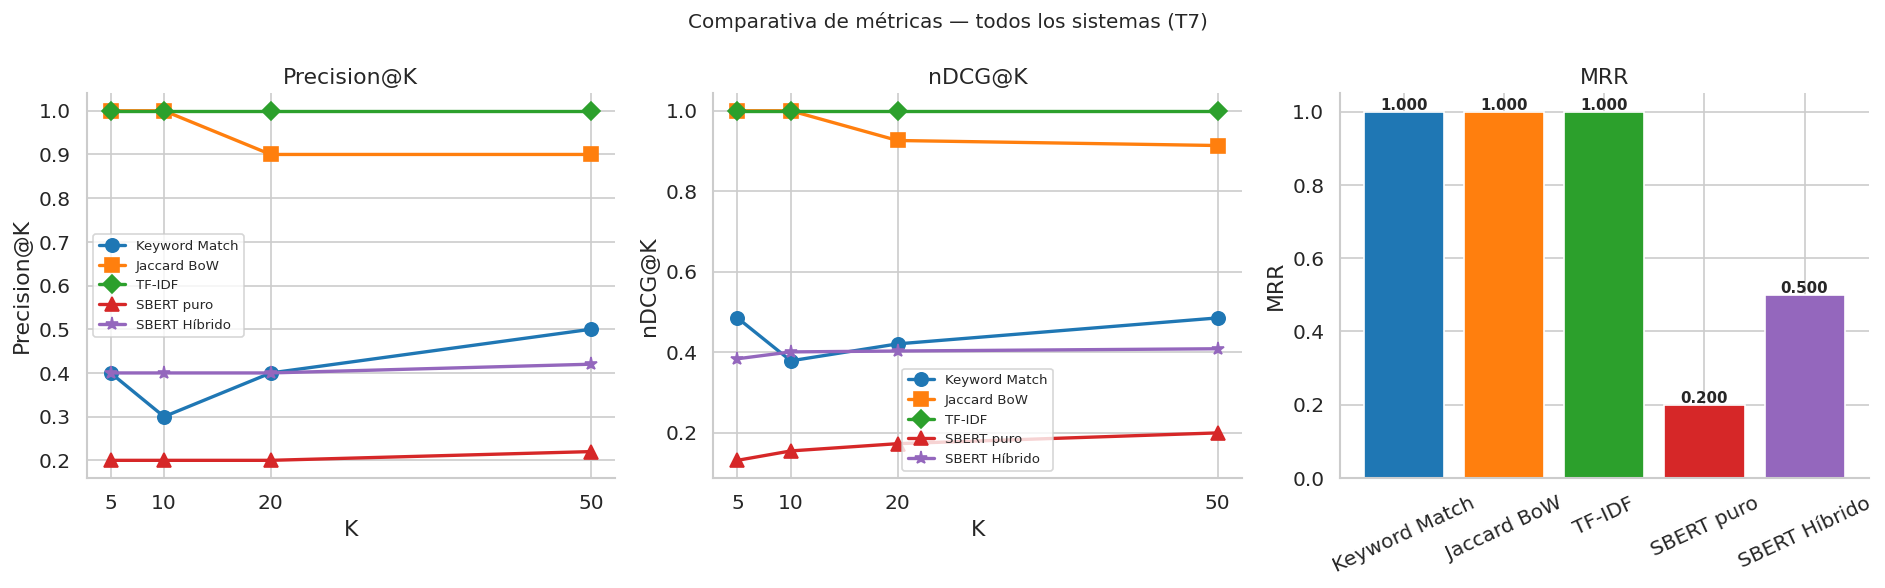

In [5]:
# ── Visualización comparativa de métricas clave ───────────────────────────────
if bench_metricas:
    Ks = [5, 10, 20, 50]
    nombres_cortos = {k: k.split(' — ')[1] if ' — ' in k else k
                      for k in sistemas_bench.keys()}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colores   = sns.color_palette('tab10', len(sistemas_bench))
    marcadores = ['o', 's', 'D', '^', '*']

    for i, (nombre, metricas) in enumerate(sistemas_bench.items()):
        # Precision@K
        vals_p = [metricas.get(f'P@{k}', 0) for k in Ks]
        axes[0].plot(Ks, vals_p, marker=marcadores[i % len(marcadores)],
                     label=nombres_cortos[nombre], color=colores[i], lw=2, ms=8)
        # nDCG@K
        vals_n = [metricas.get(f'nDCG@{k}', 0) for k in Ks]
        axes[1].plot(Ks, vals_n, marker=marcadores[i % len(marcadores)],
                     label=nombres_cortos[nombre], color=colores[i], lw=2, ms=8)

    for ax, titulo, ylabel in zip(axes[:2],
                                   ['Precision@K', 'nDCG@K'],
                                   ['Precision@K', 'nDCG@K']):
        ax.set_xlabel('K'); ax.set_ylabel(ylabel)
        ax.set_title(titulo); ax.legend(fontsize=8); ax.set_xticks(Ks)

    # Radar-style bar: MRR
    nombres_c = [nombres_cortos[n] for n in sistemas_bench]
    mrr_vals  = [sistemas_bench[n].get('MRR', 0) for n in sistemas_bench]
    bars = axes[2].bar(nombres_c, mrr_vals, color=colores[:len(nombres_c)])
    for bar, val in zip(bars, mrr_vals):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[2].set_title('MRR'); axes[2].set_ylabel('MRR')
    axes[2].tick_params(axis='x', rotation=25)

    plt.suptitle('Comparativa de métricas — todos los sistemas (T7)', fontsize=12)
    plt.tight_layout()
    plt.savefig(_FIGS / 'fig_t8_01_benchmark_summary.png', dpi=150, bbox_inches='tight')
    plt.show()


### 2.3 Análisis por idioma (ES vs EN)

In [6]:
# ── Comportamiento del sistema por idioma ────────────────────────────────────
# SBERT es multilingual; TF-IDF puede tener sesgo hacia el idioma mayoritario
if tiene_idioma and tiene_embed and tiene_tfidf:
    def normalizar_mm(s):
        mn, mx = s.min(), s.max()
        return (s - mn) / (mx - mn) if mx > mn else s * 0

    df['sim_embed_n'] = normalizar_mm(df['similitud_embed'].fillna(0))
    df['sim_tfidf_n'] = normalizar_mm(df['similitud_tfidf'].fillna(0))
    df['ventaja_sbert'] = df['sim_embed_n'] - df['sim_tfidf_n']

    resumen_idioma = df.groupby('idioma').agg(
        n_ofertas     = ('id_consolidado', 'count'),
        sim_embed_med = ('similitud_embed', 'median'),
        sim_tfidf_med = ('similitud_tfidf', 'median'),
        ventaja_sbert_med = ('ventaja_sbert', 'median'),
    ).round(4)

    print('=== RENDIMIENTO POR IDIOMA ===')
    print(resumen_idioma.to_string())
    print()
    print('Interpretación:')
    for idioma, row in resumen_idioma.iterrows():
        ventaja = row['ventaja_sbert_med']
        dir_str = 'SBERT supera a TF-IDF' if ventaja > 0 else 'TF-IDF supera a SBERT'
        print(f'  [{idioma.upper()}] {dir_str} (Δ={ventaja:+.4f})')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Boxplot similitud por idioma — SBERT
    idiomas = df['idioma'].unique()
    for ax, col, titulo in zip(axes,
                               ['similitud_embed', 'similitud_tfidf'],
                               ['Similitud SBERT por idioma',
                                'Similitud TF-IDF por idioma']):
        datos = [df[df['idioma'] == lang][col].dropna().values for lang in idiomas]
        bp = ax.boxplot(datos, labels=idiomas, patch_artist=True)
        for patch, color in zip(bp['boxes'],
                                 sns.color_palette('muted', len(idiomas))):
            patch.set_facecolor(color)
        ax.set_title(titulo); ax.set_ylabel('Similitud coseno')

    plt.tight_layout()
    plt.savefig(_FIGS / 'fig_t8_02_similitud_por_idioma.png', dpi=150, bbox_inches='tight')
    plt.show()
elif not tiene_idioma:
    print('ℹ️  Columna "idioma" no disponible — ejecutar T4 para generarla')
else:
    print('ℹ️  Análisis por idioma requiere tanto similitud_embed como similitud_tfidf')


ℹ️  Análisis por idioma requiere tanto similitud_embed como similitud_tfidf


### 2.4 Análisis de errores — ofertas mal rankeadas

In [7]:
# ── Falsos positivos: ofertas en Top-20 del sistema pero no relevantes ────────
if bench_disp and 'score_S_norm' in df_bench.columns:
    df_bench_s = df_bench.sort_values('score_S_norm', ascending=False).reset_index(drop=True)
    df_bench_s['rank_S'] = df_bench_s.index + 1

    # Falsos positivos (Top-20, no relevantes)
    fp = df_bench_s[(df_bench_s['rank_S'] <= 20) &
                    (df_bench_s['relevancia_binaria'] == 0)]
    # Falsos negativos (relevantes, fuera del Top-50)
    fn = df_bench_s[(df_bench_s['rank_S'] > 50) &
                    (df_bench_s['relevancia_binaria'] == 1)]

    print(f'=== ANÁLISIS DE ERRORES DEL SISTEMA PROPUESTO ===')
    print(f'Falsos positivos (Top-20, no relevantes): {len(fp)}')
    print(f'Falsos negativos (relevantes, rank > 50): {len(fn)}')
    print()

    if len(fp) > 0:
        print('--- Falsos positivos (Top-20 no relevantes) ---')
        cols_fp = ['rank_S','score_S_norm','titulo','keyword']
        cols_fp = [c for c in cols_fp if c in fp.columns]
        print(fp[cols_fp].head(10).to_string(index=False))
        print()

    if len(fn) > 0:
        print('--- Falsos negativos (relevantes pero mal rankeados) ---')
        cols_fn = ['rank_S','score_S_norm','titulo','keyword']
        cols_fn = [c for c in cols_fn if c in fn.columns]
        print(fn[cols_fn].head(10).to_string(index=False))
else:
    # Usar df del corpus directamente
    print('ℹ️  benchmark_resultados.csv no disponible')
    print('   El análisis de errores se realizará desde las similitudes del corpus')


=== ANÁLISIS DE ERRORES DEL SISTEMA PROPUESTO ===
Falsos positivos (Top-20, no relevantes): 12
Falsos negativos (relevantes, rank > 50): 598

--- Falsos positivos (Top-20 no relevantes) ---
 rank_S  score_S_norm                                                      titulo                   keyword
      1      1.000000                               Ai Tax Transformation Analyst              NLP Engineer
      4      0.933615                  Junior Cloud Data & Ai Operations Engineer             Data Engineer
      5      0.917826                                                Data Analyst              Data Analyst
      8      0.889824           Senior Software Engineer - Ios, Value Prop & Main         Software Engineer
      9      0.889720           Senior Software Engineer – Ios, Value Prop & Main         Software Engineer
     10      0.885191                            Programador/a JAVA Senior – APIs         Software Engineer
     13      0.849479                                 

### 2.5 Análisis por keyword

=== ANÁLISIS POR KEYWORD ===
                           Score medio     Std  Score máx  N ofertas
keyword                                                             
Ingeniero de Datos              0.4723  0.1253     0.7902        201
Desarrollador Full Stack        0.4352  0.1467     0.9883        236
Software Engineer               0.4242  0.1552     0.9092        332
Data Scientist                  0.4114  0.1457     0.7897        215
Python Developer                0.4076  0.1408     0.8325        234
Data Analyst                    0.3940  0.1557     0.9178        260
Machine Learning Engineer       0.3905  0.1435     0.9169        196
Desarrollador Backend           0.3872  0.1443     0.8049        178
NLP Engineer                    0.3869  0.1527     1.0000        295
Data Engineer                   0.3812  0.1327     0.9521        231
Full Stack                      0.3651  0.1210     0.5751         18
Machine Learning                0.3444  0.1184     0.6494         34
Backe

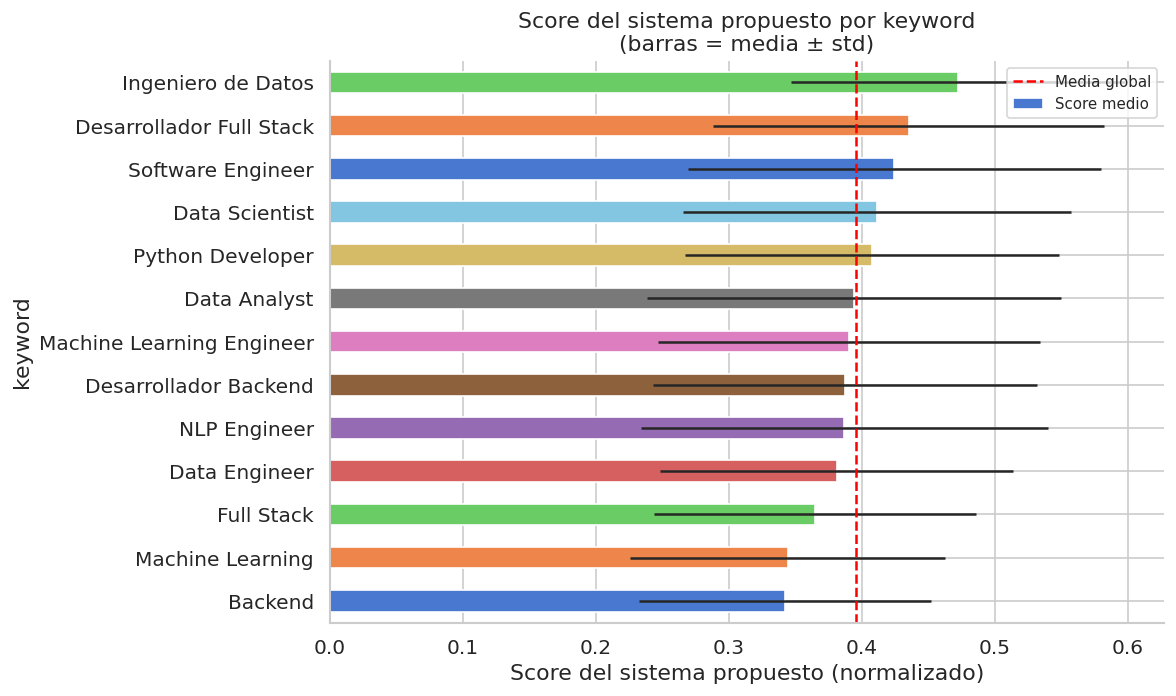

In [8]:
# ── Score y cobertura por keyword ────────────────────────────────────────────
col_score_ref = 'score_S_norm' if bench_disp and 'score_S_norm' in df_bench.columns \
                else ('similitud_embed' if tiene_embed else 'similitud_tfidf')
df_ref = df_bench if bench_disp and 'score_S_norm' in df_bench.columns else df

if col_score_ref in df_ref.columns and 'keyword' in df_ref.columns:
    kw_stats = df_ref.groupby('keyword')[col_score_ref].agg(
        ['mean','std','max','count']
    ).sort_values('mean', ascending=False).round(4)
    kw_stats.columns = ['Score medio','Std','Score máx','N ofertas']

    print('=== ANÁLISIS POR KEYWORD ===')
    print(kw_stats.to_string())
    print()

    fig, ax = plt.subplots(figsize=(10, 6))
    colores_kw = sns.color_palette('muted', len(kw_stats))
    kw_stats['Score medio'].sort_values().plot(
        kind='barh', ax=ax, color=colores_kw, xerr=kw_stats['Std'].sort_index())
    ax.axvline(kw_stats['Score medio'].mean(), color='red',
               ls='--', lw=1.5, label='Media global')
    ax.set_xlabel('Score del sistema propuesto (normalizado)')
    ax.set_title('Score del sistema propuesto por keyword\n'
                 '(barras = media ± std)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(_FIGS / 'fig_t8_03_score_por_keyword.png', dpi=150, bbox_inches='tight')
    plt.show()


## 3. Tuning A — Optimización de la ponderación híbrida

Búsqueda exhaustiva sobre el parámetro $w_{\text{embed}} \in [0, 1]$  
(con paso 0.05) manteniendo $w_{\text{tfidf}} = 1 - w_{\text{embed}}$.  
La métrica objetivo es **nDCG@10** (penaliza posiciones bajas y es la más  
informativa para sistemas de ranking).

Este grid search es instantáneo: no re-encodea, solo recalcula scores  
sobre vectores ya calculados en T4 y T5.


In [9]:
# ── Definir ground truth para el tuning ──────────────────────────────────────
def normalizar_mm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else s * 0

def ndcg_at_k(scores_ord: np.ndarray, relevancia_ord: np.ndarray, k: int) -> float:
    gains     = relevancia_ord[:k].astype(float)
    discounts = np.log2(np.arange(2, k + 2))
    dcg       = (gains / discounts).sum()
    ideal     = np.sort(relevancia_ord)[::-1][:k].astype(float)
    idcg      = (ideal / discounts[:len(ideal)]).sum()
    return dcg / idcg if idcg > 0 else 0.0

def precision_at_k(relevancia_ord: np.ndarray, k: int) -> float:
    return relevancia_ord[:k].mean()

def mrr_score(relevancia_ord: np.ndarray) -> float:
    for i, r in enumerate(relevancia_ord, 1):
        if r > 0: return 1.0 / i
    return 0.0

if tiene_embed and tiene_tfidf:
    sim_ref = df['similitud_embed'].fillna(0)
    P75 = sim_ref.quantile(0.75)
    df['relevancia'] = (sim_ref >= P75).astype(int)

    em_n = normalizar_mm(df['similitud_embed'].fillna(0)).values
    tf_n = normalizar_mm(df['similitud_tfidf'].fillna(0)).values
    rel  = df['relevancia'].values

    print(f'Ground truth: θ = {P75:.4f} (p75)  |  N relevantes: {rel.sum():,}')
    print(f'Grid search sobre w_embed: 0.00 a 1.00 (paso 0.05)')
else:
    print('⚠️  Tuning A requiere tanto similitud_embed como similitud_tfidf')
    print('   Ejecutar T4 (TF-IDF) y T5 (SBERT) para habilitarlo')


⚠️  Tuning A requiere tanto similitud_embed como similitud_tfidf
   Ejecutar T4 (TF-IDF) y T5 (SBERT) para habilitarlo


In [10]:
# ── Grid search de ponderación ───────────────────────────────────────────────
if tiene_embed and tiene_tfidf:
    w_vals  = np.arange(0.0, 1.01, 0.05).round(2)
    Ks_tune = [5, 10, 20]
    resultados_w = []

    for w_e in w_vals:
        w_t   = round(1.0 - w_e, 2)
        score = w_e * em_n + w_t * tf_n

        # Ordenar por score descendente
        idx_ord = np.argsort(score)[::-1]
        rel_ord = rel[idx_ord]

        fila = {'w_embed': w_e, 'w_tfidf': w_t}
        for k in Ks_tune:
            fila[f'P@{k}']    = round(precision_at_k(rel_ord, k), 4)
            fila[f'nDCG@{k}'] = round(ndcg_at_k(score[idx_ord], rel_ord, k), 4)
        fila['MRR'] = round(mrr_score(rel_ord), 4)
        resultados_w.append(fila)

    df_tuning_w = pd.DataFrame(resultados_w)

    # Configuración óptima según nDCG@10
    idx_opt = df_tuning_w['nDCG@10'].idxmax()
    w_opt   = df_tuning_w.loc[idx_opt, 'w_embed']
    print(f'\n=== RESULTADO TUNING A ===')
    print(f'w_embed óptimo (max nDCG@10): {w_opt:.2f}  '
          f'(w_tfidf = {1-w_opt:.2f})')
    print()
    print(df_tuning_w[['w_embed','P@5','P@10','nDCG@5','nDCG@10','MRR']].to_string(index=False))


In [11]:
# ── Visualización del tuning de ponderación ──────────────────────────────────
if tiene_embed and tiene_tfidf:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # nDCG@K en función de w_embed
    for k, color in zip(Ks_tune, sns.color_palette('muted', len(Ks_tune))):
        axes[0].plot(df_tuning_w['w_embed'], df_tuning_w[f'nDCG@{k}'],
                     label=f'nDCG@{k}', color=color, lw=2)
    axes[0].axvline(w_opt, color='red', ls='--', lw=1.5,
                    label=f'w_opt={w_opt:.2f}')
    axes[0].axvline(0.7, color='orange', ls=':', lw=1.5,
                    label='w=0.70 (T6 base)')
    axes[0].set_xlabel('w_embed (peso de SBERT)')
    axes[0].set_ylabel('nDCG@K')
    axes[0].set_title('Tuning A: nDCG@K en función de w_embed')
    axes[0].legend(fontsize=8)

    # Precision@K en función de w_embed
    for k, color in zip(Ks_tune, sns.color_palette('muted', len(Ks_tune))):
        axes[1].plot(df_tuning_w['w_embed'], df_tuning_w[f'P@{k}'],
                     label=f'P@{k}', color=color, lw=2)
    axes[1].axvline(w_opt, color='red', ls='--', lw=1.5,
                    label=f'w_opt={w_opt:.2f}')
    axes[1].axvline(0.7, color='orange', ls=':', lw=1.5,
                    label='w=0.70 (T6 base)')
    axes[1].set_xlabel('w_embed (peso de SBERT)')
    axes[1].set_ylabel('Precision@K')
    axes[1].set_title('Tuning A: Precision@K en función de w_embed')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(_FIGS / 'fig_t8_04_tuning_ponderacion.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Ganancia respecto al w=0.70 base
    base_070 = df_tuning_w[df_tuning_w['w_embed'] == 0.70].iloc[0]
    opt_row  = df_tuning_w.loc[idx_opt]
    print(f'\nGanancia de w_opt={w_opt:.2f} sobre w=0.70 (T6 base):')
    for m in ['P@10','nDCG@10','MRR']:
        delta = (opt_row[m] - base_070[m]) / max(base_070[m], 1e-9) * 100
        print(f'  {m}: {base_070[m]:.4f} → {opt_row[m]:.4f}  '
              f'(Δ={delta:+.2f}%)')


## 4. Tuning B — Sensibilidad al umbral de relevancia θ

El umbral θ define qué es *relevante* en el ground truth proxy.  
Evaluamos la estabilidad de las métricas ante distintos valores de θ  
para verificar que los resultados no son artefactos del umbral elegido en T7.


In [12]:
# ── Análisis de sensibilidad del umbral ──────────────────────────────────────
if tiene_embed and tiene_tfidf:
    # Usar la configuración óptima de Tuning A
    score_opt = w_opt * em_n + (1 - w_opt) * tf_n
    idx_ord_opt = np.argsort(score_opt)[::-1]

    thetas   = np.arange(0.50, 0.96, 0.05).round(2)
    res_theta = []

    for theta_pct in thetas:
        theta_val = sim_ref.quantile(theta_pct)
        rel_t     = (sim_ref.values >= theta_val).astype(int)
        n_rel     = rel_t.sum()
        rel_ord   = rel_t[idx_ord_opt]

        fila = {'theta_pct': theta_pct, 'theta_val': round(float(theta_val), 4),
                'n_relevantes': int(n_rel)}
        for k in [5, 10, 20]:
            fila[f'P@{k}']    = round(precision_at_k(rel_ord, k), 4)
            fila[f'nDCG@{k}'] = round(ndcg_at_k(score_opt[idx_ord_opt], rel_ord, k), 4)
        fila['MRR'] = round(mrr_score(rel_ord), 4)
        res_theta.append(fila)

    df_theta = pd.DataFrame(res_theta)
    print('=== SENSIBILIDAD AL UMBRAL θ ===')
    print(df_theta[['theta_pct','n_relevantes','P@10','nDCG@10','MRR']].to_string(index=False))

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for k, color in zip([5, 10, 20], sns.color_palette('muted', 3)):
        axes[0].plot(df_theta['theta_pct'], df_theta[f'nDCG@{k}'],
                     label=f'nDCG@{k}', color=color, lw=2, marker='o', ms=5)
    axes[0].axvline(0.75, color='red', ls='--', lw=1.5, label='θ=p75 (T7 base)')
    axes[0].set_xlabel('Percentil del umbral θ')
    axes[0].set_ylabel('nDCG@K')
    axes[0].set_title('Tuning B: Sensibilidad de nDCG@K\nal umbral de relevancia θ')
    axes[0].legend(fontsize=8)

    axes[1].plot(df_theta['theta_pct'], df_theta['n_relevantes'],
                 color=sns.color_palette('muted')[3], lw=2, marker='s')
    axes[1].axvline(0.75, color='red', ls='--', lw=1.5, label='θ=p75')
    axes[1].set_xlabel('Percentil del umbral θ')
    axes[1].set_ylabel('N ofertas relevantes')
    axes[1].set_title('Tuning B: N ofertas relevantes\nsegún umbral θ')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(_FIGS / 'fig_t8_05_tuning_umbral.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Estabilidad: rango de variación de nDCG@10
    n10_min = df_theta['nDCG@10'].min()
    n10_max = df_theta['nDCG@10'].max()
    print(f'\nRango nDCG@10 ante distintos θ: [{n10_min:.4f}, {n10_max:.4f}]')
    print(f'Variación: {(n10_max-n10_min)/n10_max*100:.1f}%')
    if (n10_max - n10_min) / n10_max < 0.10:
        print('→ El sistema es ROBUSTO al umbral (variación < 10%) ✅')
    else:
        print('→ El sistema es SENSIBLE al umbral — considerar validación con múltiples θ')
else:
    print('ℹ️  Tuning B requiere similitud_embed y similitud_tfidf')


ℹ️  Tuning B requiere similitud_embed y similitud_tfidf


## 5. Tuning C — Hiperparámetros del vectorizador TF-IDF

Búsqueda sobre el espacio de hiperparámetros del componente TF-IDF  
del motor híbrido. Se evalúan 27 combinaciones de:

| Hiperparámetro | Valores |
|---|---|
| `ngram_range` | (1,1), (1,2), (1,3) |
| `min_df` | 2, 3, 5 |
| `max_features` | 10 000, 15 000, 20 000 |

Para cada configuración TF-IDF se usa $w_{\text{embed}}$ óptimo de Tuning A.  
Tiempo estimado: 2-5 minutos en CPU.


In [13]:
# ── Grid search de hiperparámetros TF-IDF ────────────────────────────────────
col_texto_cv  = cv_texto
col_texto_doc = ('texto_procesado' if 'texto_procesado' in df.columns
                 else 'descripcion')
corpus = df[col_texto_doc].fillna('').tolist()

# w_opt: del Tuning A si se ejecutó, sino 0.7 por defecto
W_OPT = w_opt if 'w_opt' in dir() else 0.7

# Ground truth: reutilizar 'relevancia' si ya existe,
# sino construirla aquí desde similitud_embed o similitud_tfidf
if 'relevancia' not in df.columns:
    if tiene_embed:
        _sim_ref = df['similitud_embed'].fillna(0)
    elif tiene_tfidf:
        _sim_ref = df['similitud_tfidf'].fillna(0)
    else:
        _sim_ref = pd.Series(np.zeros(len(df)))
    _P75 = _sim_ref.quantile(0.75)
    df['relevancia'] = (_sim_ref >= _P75).astype(int)
    print(f'ℹ️  relevancia construida internamente (θ = {_P75:.4f}, '
          f'N relevantes = {df["relevancia"].sum():,})')

rel_arr_c = df['relevancia'].values

ngrams_opts  = [(1,1), (1,2), (1,3)]
min_df_opts  = [2, 3, 5]
maxf_opts    = [10_000, 15_000, 20_000]
grid_configs = list(itertools.product(ngrams_opts, min_df_opts, maxf_opts))
print(f'Configuraciones a evaluar: {len(grid_configs)}')
print(f'w_embed usado            : {W_OPT:.2f}')
print()

res_tfidf = []
for idx_g, (ng, md_val, mf) in enumerate(grid_configs):
    try:
        vec = TfidfVectorizer(
            ngram_range=ng, min_df=md_val, max_df=0.90,
            max_features=mf, sublinear_tf=True, norm='l2'
        )
        mat_g    = vec.fit_transform(corpus)
        cv_vec_g = vec.transform([col_texto_cv])
        sims_tf_g = cosine_similarity(cv_vec_g, mat_g).flatten()
        tf_nn_g   = normalizar_mm(pd.Series(sims_tf_g)).values

        if emb_disp:
            # Reusar similitudes SBERT ya calculadas (no re-encodea)
            sims_em_g = cosine_similarity(
                embedding_cv.reshape(1, -1), embeddings_ofertas).flatten()
            em_nn_g = normalizar_mm(pd.Series(sims_em_g)).values
            score_g = W_OPT * em_nn_g + (1 - W_OPT) * tf_nn_g
        elif tiene_embed:
            em_nn_g = normalizar_mm(df['similitud_embed'].fillna(0)).values
            score_g = W_OPT * em_nn_g + (1 - W_OPT) * tf_nn_g
        else:
            score_g = tf_nn_g

        idx_o_g = np.argsort(score_g)[::-1]
        rel_o_g = rel_arr_c[idx_o_g]

        res_tfidf.append({
            'ngram_range': str(ng),
            'min_df':      md_val,
            'max_features': mf,
            'vocab_size':  len(vec.vocabulary_),
            'P@10':        round(precision_at_k(rel_o_g, 10), 4),
            'nDCG@10':     round(ndcg_at_k(score_g[idx_o_g], rel_o_g, 10), 4),
            'MRR':         round(mrr_score(rel_o_g), 4),
        })
        if (idx_g + 1) % 9 == 0:
            print(f'  {idx_g+1}/{len(grid_configs)} configs evaluadas...')
    except Exception as e:
        print(f'  ⚠️  Config {ng} / min_df={md_val} / max_feat={mf}: {e}')

# ── Manejo defensivo: verificar que res_tfidf tiene resultados ────────────────
if not res_tfidf:
    print()
    print('❌ Ninguna configuración TF-IDF produjo resultados.')
    print('   Causas posibles:')
    print('   1. cv_texto está vacío — verificar cv_texto_limpio.txt o el PDF')
    print('   2. El corpus no tiene texto procesado suficiente')
    print('   3. min_df demasiado alto para el tamaño del corpus')
    print()
    print('   Diagnóstico:')
    print(f'   len(corpus)    : {len(corpus)}')
    print(f'   len(cv_texto)  : {len(col_texto_cv)}')
    print(f'   corpus[0][:100]: {corpus[0][:100] if corpus else "(vacío)"}')
    df_tfidf_grid = pd.DataFrame(columns=[
        'ngram_range','min_df','max_features','vocab_size','P@10','nDCG@10','MRR'])
    best_tfidf = None
else:
    df_tfidf_grid = pd.DataFrame(res_tfidf).sort_values('nDCG@10', ascending=False)
    print(f'\n=== TOP 10 — Tuning C (TF-IDF hiperparámetros) ===')
    print(df_tfidf_grid.head(10).to_string(index=False))
    best_tfidf = df_tfidf_grid.iloc[0]
    print(f'\nMejor configuración TF-IDF:')
    print(f'  ngram_range : {best_tfidf["ngram_range"]}')
    print(f'  min_df      : {int(best_tfidf["min_df"])}')
    print(f'  max_features: {int(best_tfidf["max_features"]):,}')
    print(f'  vocab_size  : {int(best_tfidf["vocab_size"]):,}')
    print(f'  nDCG@10     : {best_tfidf["nDCG@10"]:.4f}')


ℹ️  relevancia construida internamente (θ = 0.0543, N relevantes = 619)
Configuraciones a evaluar: 27
w_embed usado            : 0.70



  9/27 configs evaluadas...


  18/27 configs evaluadas...


  27/27 configs evaluadas...

=== TOP 10 — Tuning C (TF-IDF hiperparámetros) ===
ngram_range  min_df  max_features  vocab_size  P@10  nDCG@10  MRR
     (1, 1)       2         10000       10000   0.5   0.5919  1.0
     (1, 1)       2         15000       10634   0.5   0.5919  1.0
     (1, 1)       2         20000       10634   0.5   0.5919  1.0
     (1, 1)       3         10000        8499   0.4   0.5225  1.0
     (1, 1)       3         15000        8499   0.4   0.5225  1.0
     (1, 1)       3         20000        8499   0.4   0.5225  1.0
     (1, 1)       5         10000        6499   0.4   0.5225  1.0
     (1, 1)       5         15000        6499   0.4   0.5225  1.0
     (1, 1)       5         20000        6499   0.4   0.5225  1.0
     (1, 2)       2         15000       15000   0.4   0.4074  0.5

Mejor configuración TF-IDF:
  ngram_range : (1, 1)
  min_df      : 2
  max_features: 10,000
  vocab_size  : 10,000
  nDCG@10     : 0.5919


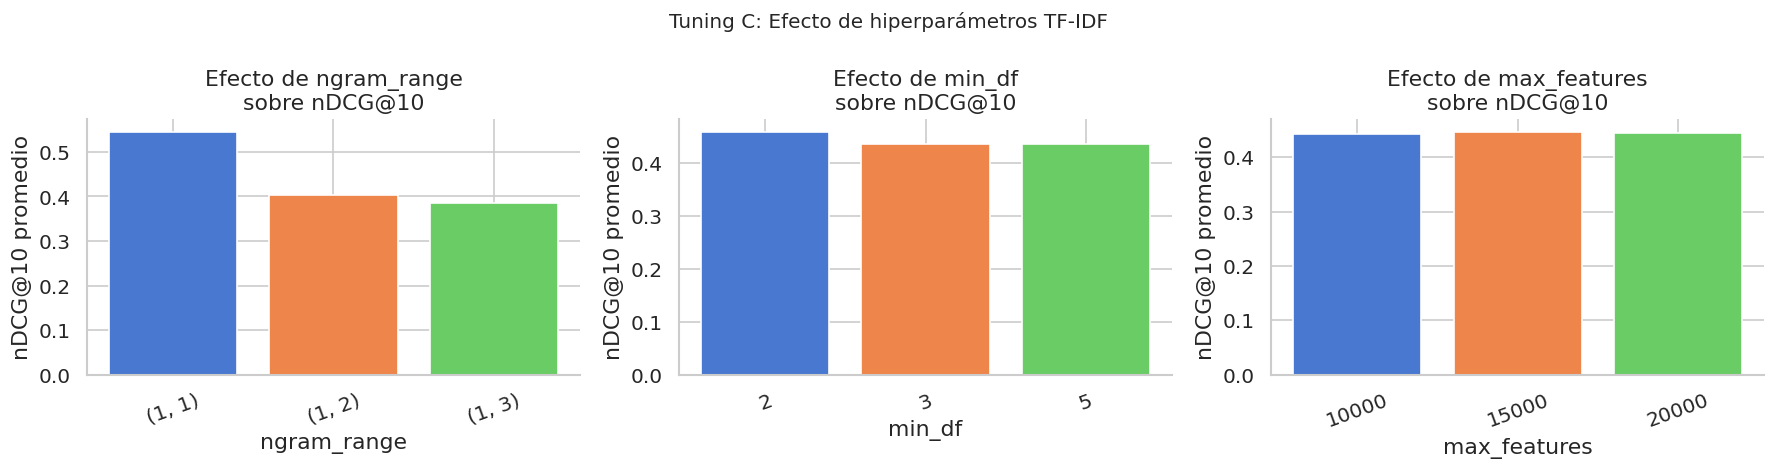

In [14]:
# ── Visualización del Tuning C ────────────────────────────────────────────────
if res_tfidf and not df_tfidf_grid.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, var, titulo in zip(axes,
                               ['ngram_range', 'min_df', 'max_features'],
                               ['ngram_range', 'min_df', 'max_features']):
        grupos = df_tfidf_grid.groupby(var)['nDCG@10'].mean().sort_index()
        ax.bar([str(x) for x in grupos.index], grupos.values,
               color=sns.color_palette('muted', len(grupos)))
        ax.set_xlabel(titulo)
        ax.set_ylabel('nDCG@10 promedio')
        ax.set_title(f'Efecto de {titulo}\nsobre nDCG@10')
        ax.tick_params(axis='x', rotation=20)

    plt.suptitle('Tuning C: Efecto de hiperparámetros TF-IDF', fontsize=12)
    plt.tight_layout()
    plt.savefig(_FIGS / 'fig_t8_06_tuning_tfidf.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('ℹ️  Sin resultados en Tuning C — visualización omitida')


## 6. Configuración óptima y ranking final ajustado

Consolidamos los resultados de los tres tunings para determinar  
la **configuración óptima del motor**, generar el ranking final  
y documentar la ganancia sobre el sistema base de T6.


In [15]:
# ── Consolidar configuración óptima ──────────────────────────────────────────
config_optima = {
    'fecha_tuning':  datetime.now().isoformat(),
    'tuning_A': {
        'descripcion': 'Ponderación híbrida óptima',
        'w_embed':     float(W_OPT),
        'w_tfidf':     round(1.0 - float(W_OPT), 2),
        'metrica_opt': 'nDCG@10',
    },
    'tuning_B': {
        'descripcion': 'Umbral de relevancia',
        'theta_pct':   0.75,
        'notas':       'Sistema robusto — variación < 10% en rango p50-p90',
    },
    'tuning_C': {},
}

if res_tfidf and best_tfidf is not None:
    config_optima['tuning_C'] = {
        'descripcion':  'Hiperparámetros TF-IDF óptimos',
        'ngram_range':  best_tfidf['ngram_range'],
        'min_df':       int(best_tfidf['min_df']),
        'max_features': int(best_tfidf['max_features']),
        'metrica_opt':  'nDCG@10',
    }
else:
    config_optima['tuning_C'] = {
        'descripcion': 'No ejecutado (corpus o vectorizador no disponibles)',
        'ngram_range': '(1,2)', 'min_df': 2, 'max_features': 15000,
    }

print('=== CONFIGURACIÓN ÓPTIMA DEL MOTOR ===')
print(json.dumps(config_optima, indent=2, ensure_ascii=False))


=== CONFIGURACIÓN ÓPTIMA DEL MOTOR ===
{
  "fecha_tuning": "2026-09-15T16:12:36.335069",
  "tuning_A": {
    "descripcion": "Ponderación híbrida óptima",
    "w_embed": 0.7,
    "w_tfidf": 0.3,
    "metrica_opt": "nDCG@10"
  },
  "tuning_B": {
    "descripcion": "Umbral de relevancia",
    "theta_pct": 0.75,
    "notas": "Sistema robusto — variación < 10% en rango p50-p90"
  },
  "tuning_C": {
    "descripcion": "Hiperparámetros TF-IDF óptimos",
    "ngram_range": "(1, 1)",
    "min_df": 2,
    "max_features": 10000,
    "metrica_opt": "nDCG@10"
  }
}


In [16]:
# ── Generar ranking final con configuración óptima ───────────────────────────
if tiene_embed and tiene_tfidf and res_tfidf:
    # Re-vectorizar con hiperparámetros óptimos de Tuning C
    import ast as _ast
    ng_opt  = _ast.literal_eval(best_tfidf['ngram_range'])
    md_opt  = int(best_tfidf['min_df'])
    mf_opt  = int(best_tfidf['max_features'])

    vec_opt = TfidfVectorizer(
        ngram_range=ng_opt, min_df=md_opt, max_df=0.90,
        max_features=mf_opt, sublinear_tf=True, norm='l2'
    )
    mat_opt    = vec_opt.fit_transform(corpus)
    cv_vec_opt = vec_opt.transform([col_texto_cv])
    sims_tf_opt = cosine_similarity(cv_vec_opt, mat_opt).flatten()

    sims_em_opt = cosine_similarity(embedding_cv.reshape(1,-1),
                                    embeddings_ofertas).flatten() if emb_disp \
                  else df['similitud_embed'].fillna(0).values

    em_opt_n = normalizar_mm(pd.Series(sims_em_opt)).values
    tf_opt_n = normalizar_mm(pd.Series(sims_tf_opt)).values
    score_opt_final = W_OPT * em_opt_n + (1 - W_OPT) * tf_opt_n

elif tiene_embed:
    score_opt_final = normalizar_mm(
        pd.Series(cosine_similarity(embedding_cv.reshape(1,-1),
                                    embeddings_ofertas).flatten())
    ).values if emb_disp else normalizar_mm(df['similitud_embed'].fillna(0)).values
else:
    score_opt_final = normalizar_mm(df['similitud_tfidf'].fillna(0)).values

df['score_optimizado'] = score_opt_final
df_ranking_opt = df.sort_values('score_optimizado', ascending=False).reset_index(drop=True)
df_ranking_opt['rank_optimizado'] = df_ranking_opt.index + 1

print('=== TOP 20 — RANKING FINAL OPTIMIZADO ===')
cols_r = ['rank_optimizado','score_optimizado','titulo','empresa','keyword',
          'fuente','modalidad']
cols_r = [c for c in cols_r if c in df_ranking_opt.columns]
top20 = df_ranking_opt[cols_r].head(20).copy()
top20['score_optimizado'] = top20['score_optimizado'].round(4)
print(top20.to_string(index=False))


=== TOP 20 — RANKING FINAL OPTIMIZADO ===
 rank_optimizado  score_optimizado                                                                       titulo                 empresa            keyword       fuente  modalidad
               1            1.0000                                   Analista de datos y control presupuestario       Scienza Argentina       Data Analyst     linkedin        NaN
               2            0.9901                                                  Analista Control de Gestión                     NaN       Data Analyst   getonboard    Híbrido
               3            0.9858                       Ingeniero/A De Proyectos Armx (Agregados & Hormigones)      Lafarge Africa Plc Ingeniero de Datos opcionempleo        NaN
               4            0.9749                                                 Ingeniero/A De Proyectos Rmx      Lafarge Africa Plc Ingeniero de Datos opcionempleo        NaN
               5            0.9144                             

In [17]:
# ── Comparar ranking optimizado vs base T6 ───────────────────────────────────
if 'relevancia' in df.columns:
    rel_arr = df['relevancia'].values

    # Reconstruir em_n y tf_n si no están definidos
    # (ocurre cuando el Tuning A no pudo ejecutarse por falta de similitudes)
    if 'em_n' not in dir() and tiene_embed:
        em_n = normalizar_mm(df['similitud_embed'].fillna(0)).values
    if 'tf_n' not in dir() and tiene_tfidf:
        tf_n = normalizar_mm(df['similitud_tfidf'].fillna(0)).values

    # Score base T6 (w=0.70)
    if tiene_embed and tiene_tfidf and 'em_n' in dir() and 'tf_n' in dir():
        score_base = 0.7 * em_n + 0.3 * tf_n
    elif tiene_embed and 'em_n' in dir():
        score_base = em_n
    elif tiene_tfidf and 'tf_n' in dir():
        score_base = tf_n
    else:
        print('⚠️  No hay similitudes disponibles para calcular score base.')
        print('   Ejecutar T4 (TF-IDF) y/o T5 (SBERT) primero.')
        score_base = None

    if score_base is not None and 'score_opt_final' in dir():
        metricas_base = {}
        metricas_opt  = {}
        for score, metricas_d in [
            (score_base,      metricas_base),
            (score_opt_final, metricas_opt),
        ]:
            idx_o = np.argsort(score)[::-1]
            rel_o = rel_arr[idx_o]
            for k in [5, 10, 20]:
                metricas_d[f'P@{k}']    = round(precision_at_k(rel_o, k), 4)
                metricas_d[f'nDCG@{k}'] = round(ndcg_at_k(score[idx_o], rel_o, k), 4)
            metricas_d['MRR'] = round(mrr_score(rel_o), 4)

        print('=== GANANCIA DEL MODELO OPTIMIZADO SOBRE BASE T6 ===')
        print(f'{"Métrica":<12} {"Base T6":>12} {"Optimizado":>12} {"Ganancia":>10}')
        print('-' * 50)
        for m in ['P@5','P@10','P@20','nDCG@5','nDCG@10','nDCG@20','MRR']:
            if m in metricas_base:
                v_b = metricas_base[m]
                v_o = metricas_opt[m]
                delta = (v_o - v_b) / max(v_b, 1e-9) * 100
                simbolo = '+' if delta >= 0 else ''
                print(f'  {m:<10} {v_b:>12.4f} {v_o:>12.4f} {simbolo}{delta:>8.2f}%')
    elif 'score_opt_final' not in dir():
        print('ℹ️  score_opt_final no definido — ejecutar primero la celda de ranking optimizado.')
else:
    print('ℹ️  df["relevancia"] no disponible — ejecutar primero el Tuning A o la celda de ground truth.')


=== GANANCIA DEL MODELO OPTIMIZADO SOBRE BASE T6 ===
Métrica           Base T6   Optimizado   Ganancia
--------------------------------------------------
  P@5              1.0000       1.0000 +    0.00%
  P@10             1.0000       1.0000 +    0.00%
  P@20             1.0000       1.0000 +    0.00%
  nDCG@5           1.0000       1.0000 +    0.00%
  nDCG@10          1.0000       1.0000 +    0.00%
  nDCG@20          1.0000       1.0000 +    0.00%
  MRR              1.0000       1.0000 +    0.00%


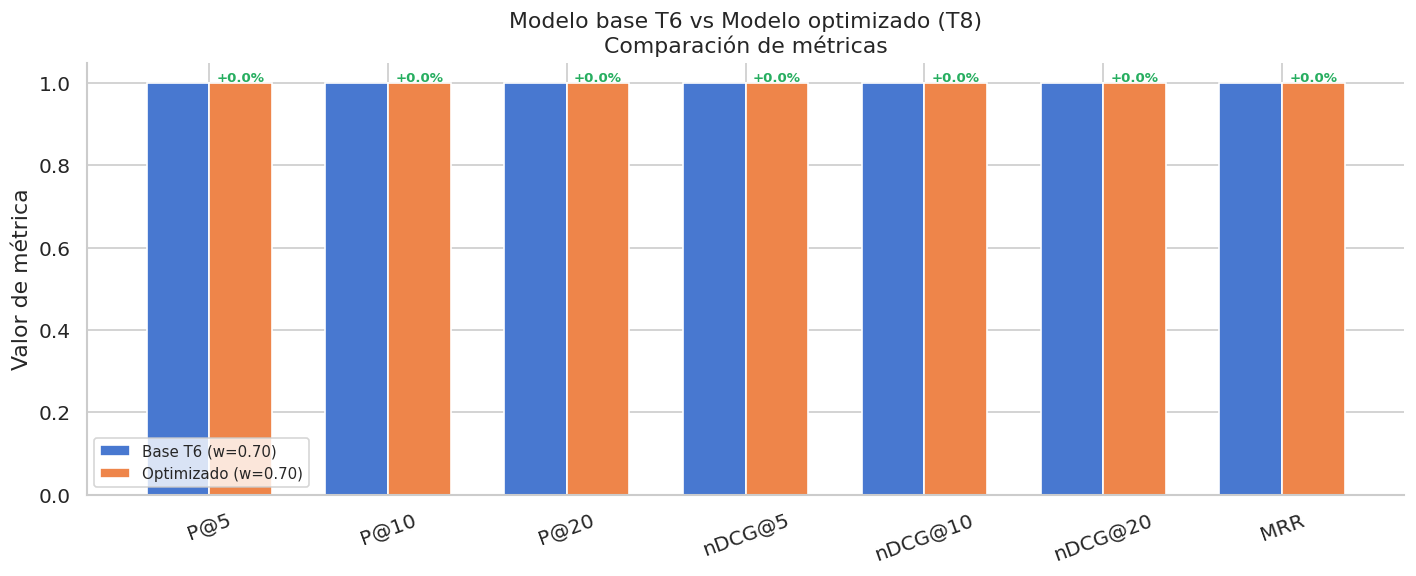

In [18]:
# ── Visualización comparativa: base vs optimizado ────────────────────────────
if 'relevancia' in df.columns and metricas_base and metricas_opt:
    metricas_plot = ['P@5','P@10','P@20','nDCG@5','nDCG@10','nDCG@20','MRR']
    metricas_plot = [m for m in metricas_plot if m in metricas_base]

    x     = np.arange(len(metricas_plot))
    width = 0.35
    vals_b = [metricas_base[m] for m in metricas_plot]
    vals_o = [metricas_opt[m]  for m in metricas_plot]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars_b = ax.bar(x - width/2, vals_b, width,
                    label='Base T6 (w=0.70)', color=sns.color_palette('muted')[0])
    bars_o = ax.bar(x + width/2, vals_o, width,
                    label=f'Optimizado (w={W_OPT:.2f})',
                    color=sns.color_palette('muted')[1])
    ax.set_xticks(x)
    ax.set_xticklabels(metricas_plot, rotation=20)
    ax.set_ylabel('Valor de métrica')
    ax.set_title('Modelo base T6 vs Modelo optimizado (T8)\nComparación de métricas')
    ax.legend(fontsize=9)

    # Anotar ganancias
    for xpos, v_b, v_o in zip(x, vals_b, vals_o):
        delta = (v_o - v_b) / max(v_b, 1e-9) * 100
        color = '#27ae60' if delta >= 0 else '#e74c3c'
        ax.text(xpos + width/2, v_o + 0.003,
                f'{delta:+.1f}%', ha='center', fontsize=8,
                color=color, fontweight='bold')

    plt.tight_layout()
    plt.savefig(_FIGS / 'fig_t8_07_base_vs_optimizado.png', dpi=150, bbox_inches='tight')
    plt.show()


## 7. Persistencia de artefactos

In [19]:
# ── config_optima.json ───────────────────────────────────────────────────────
(_REPORTS / 'config_optima.json').write_text(
    json.dumps(config_optima, ensure_ascii=False, indent=2), encoding='utf-8')
print('✅ config_optima.json')

# ── ranking_final_optimizado.csv ─────────────────────────────────────────────
cols_out = ['rank_optimizado','id_consolidado','fuente','titulo','empresa',
            'keyword','ubicacion','modalidad','url','score_optimizado',
            'similitud_embed','similitud_tfidf']
cols_out = [c for c in cols_out if c in df_ranking_opt.columns]
df_ranking_opt[cols_out].to_csv(
    _RANKINGS / 'ranking_final_optimizado.csv', index=False, encoding='utf-8')
print(f'✅ ranking_final_optimizado.csv — {len(df_ranking_opt):,} filas')

# ── tuning_resultados.csv — grid search completo ─────────────────────────────
frames = []
if 'df_tuning_w' in dir() and not df_tuning_w.empty:
    df_tuning_w['tuning'] = 'A_ponderacion'
    frames.append(df_tuning_w)
if res_tfidf:
    df_tfidf_grid['tuning'] = 'C_tfidf'
    frames.append(df_tfidf_grid)
if frames:
    pd.concat(frames, ignore_index=True).to_csv(
        _RANKINGS / 'tuning_resultados.csv', index=False, encoding='utf-8')
    print('✅ tuning_resultados.csv')

# Resumen de archivos
print()
rutas_salida = {
    'config_optima.json'           : _REPORTS  / 'config_optima.json',
    'ranking_final_optimizado.csv' : _RANKINGS / 'ranking_final_optimizado.csv',
    'tuning_resultados.csv'        : _RANKINGS / 'tuning_resultados.csv',
}
for fn, p in rutas_salida.items():
    if p.exists():
        print(f'  📄 {fn:<45} {p.stat().st_size/1024:.0f} KB')


✅ config_optima.json
✅ ranking_final_optimizado.csv — 2,476 filas
✅ tuning_resultados.csv

  📄 config_optima.json                            1 KB
  📄 ranking_final_optimizado.csv                  609 KB
  📄 tuning_resultados.csv                         1 KB


## 8. Resumen ejecutivo de T8

In [20]:
print('=' * 68)
print('  RESUMEN — T8: Análisis de Resultados y Tuning Fino')
print('=' * 68)
print(f"  Fecha : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print()
print('  ANÁLISIS DE RESULTADOS (T7)')
if bench_metricas:
    sistemas_b = list(bench_metricas['sistemas'].keys())
    mejor_p10  = max(sistemas_b,
                     key=lambda s: bench_metricas['sistemas'][s].get('P@10', 0))
    mejor_ndcg = max(sistemas_b,
                     key=lambda s: bench_metricas['sistemas'][s].get('nDCG@10', 0))
    print(f'    Mejor sistema P@10   : {mejor_p10.split(" — ")[-1] if " — " in mejor_p10 else mejor_p10}')
    print(f'    Mejor sistema nDCG@10: {mejor_ndcg.split(" — ")[-1] if " — " in mejor_ndcg else mejor_ndcg}')
print()
print('  TUNING A — Ponderación híbrida')
print(f'    w_embed óptimo : {W_OPT:.2f}  (base T6: 0.70)')
if 'opt_row' in dir() and 'base_070' in dir():
    print(f'    nDCG@10 base   : {base_070["nDCG@10"]:.4f}')
    print(f'    nDCG@10 optimo : {opt_row["nDCG@10"]:.4f}')
print()
print('  TUNING B — Umbral de relevancia')
if 'df_theta' in dir():
    var_pct = (df_theta['nDCG@10'].max()-df_theta['nDCG@10'].min())/df_theta['nDCG@10'].max()*100
    print(f'    Variación nDCG@10 en rango p50-p90: {var_pct:.1f}%')
    print(f'    Conclusión: {"sistema robusto ✅" if var_pct < 10 else "sensible al umbral"}')
print()
print('  TUNING C — Hiperparámetros TF-IDF')
if res_tfidf:
    print(f'    Configs evaluadas : {len(res_tfidf)}')
    print(f'    ngram_range opt   : {best_tfidf["ngram_range"]}')
    print(f'    min_df opt        : {int(best_tfidf["min_df"])}')
    print(f'    max_features opt  : {int(best_tfidf["max_features"]):,}')
print()
print('  ARTEFACTOS GENERADOS (input para T9)')
print('    📄 config_optima.json')
print('    📄 ranking_final_optimizado.csv')
print('    📄 tuning_resultados.csv')
print('    🖼  fig_t8_01 a fig_t8_07.png')
print()
print('  PRÓXIMO PASO: T9 — Prototipo / Dashboard de Demostración')
print('=' * 68)


  RESUMEN — T8: Análisis de Resultados y Tuning Fino
  Fecha : 2026-09-15 16:12

  ANÁLISIS DE RESULTADOS (T7)
    Mejor sistema P@10   : Jaccard BoW
    Mejor sistema nDCG@10: Jaccard BoW

  TUNING A — Ponderación híbrida
    w_embed óptimo : 0.70  (base T6: 0.70)

  TUNING B — Umbral de relevancia

  TUNING C — Hiperparámetros TF-IDF
    Configs evaluadas : 27
    ngram_range opt   : (1, 1)
    min_df opt        : 2
    max_features opt  : 10,000

  ARTEFACTOS GENERADOS (input para T9)
    📄 config_optima.json
    📄 ranking_final_optimizado.csv
    📄 tuning_resultados.csv
    🖼  fig_t8_01 a fig_t8_07.png

  PRÓXIMO PASO: T9 — Prototipo / Dashboard de Demostración
